In [1]:
# This example is from:
# https://quantum.cloud.ibm.com/docs/en/tutorials/spin-chain-vqe

# Modified for use with Quantum Rings SDK

## Setup

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
 
from scipy.optimize import minimize
from typing import Sequence
 
 
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives.base import BaseEstimatorV2
from qiskit.circuit.library import XGate
from qiskit.circuit.library import efficient_su2
from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.passes.scheduling import (
    ALAPScheduleAnalysis,
    PadDynamicalDecoupling,
)
 
#from qiskit_ibm_runtime import QiskitRuntimeService
#from qiskit_ibm_runtime import Session, Estimator
 
#from qiskit_ibm_catalog import QiskitServerless, QiskitFunction

from quantumrings.toolkit.qiskit import QrRuntimeService
from quantumrings.toolkit.qiskit import QrEstimatorV2 as Estimator
from quantumrings.toolkit.qiskit import QrSession as Session

my_token = os.environ["QR_TOKEN"]
my_account = os.environ["QR_ACCOUNT"]
my_backend = "scarlet_quantum_rings"


In [3]:
def visualize_results(results):
    plt.plot(results["cost_history"], lw=2)
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.show()
 
 
def build_callback(
    ansatz: QuantumCircuit,
    hamiltonian: SparsePauliOp,
    estimator: Estimator,
    callback_dict: dict,
):
    def callback(current_vector):
        # Keep track of the number of iterations
        callback_dict["iters"] += 1
        # Set the prev_vector to the latest one
        callback_dict["prev_vector"] = current_vector
        # Compute the value of the cost function at the current vector
        current_cost = (
            estimator.run([(ansatz, hamiltonian, [current_vector])])
            .result()[0]
            .data.evs[0]
        )
        callback_dict["cost_history"].append(current_cost)
        # Print to screen on single line
        print(
            "Iters. done: {} [Current cost: {}]".format(
                callback_dict["iters"], current_cost
            ),
            end="\r",
            flush=True,
        )
 
    return callback

## Step 1: Map classical inputs to a quantum problem

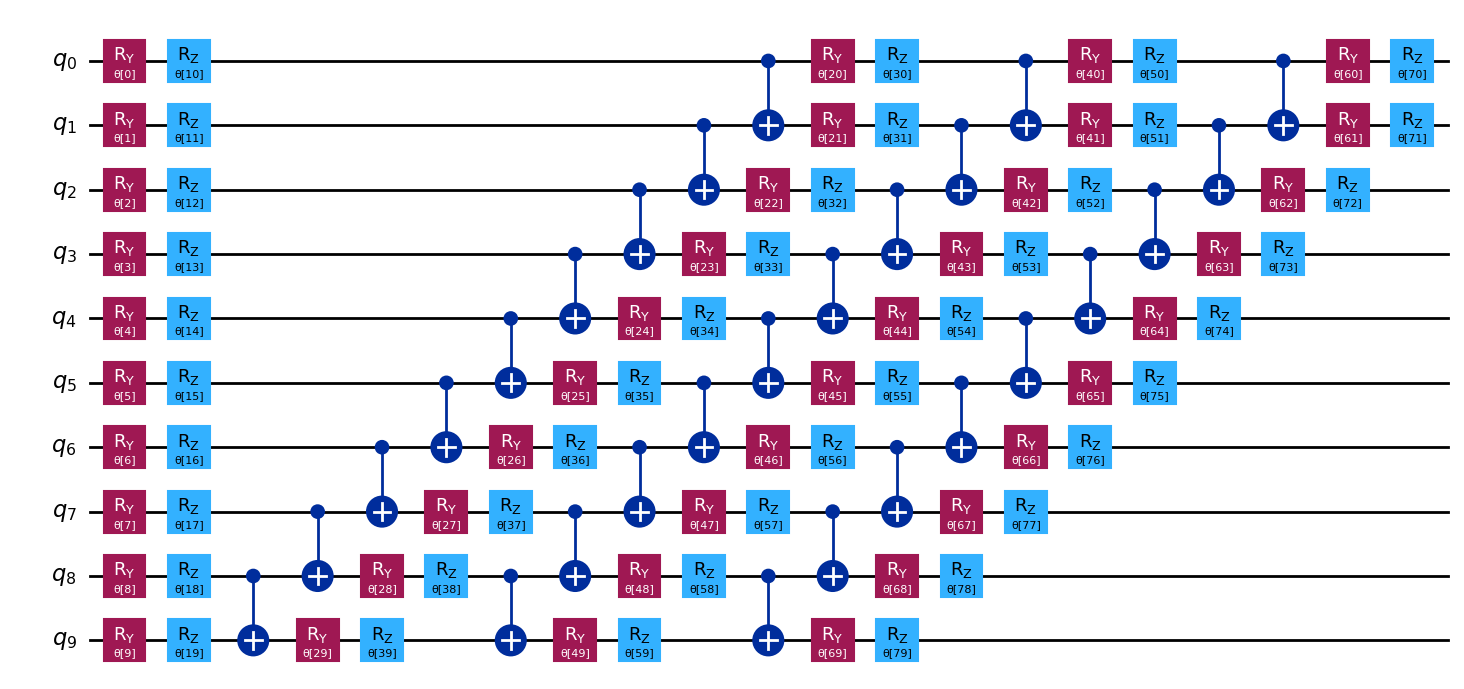

In [4]:
num_spins = 10
ansatz = efficient_su2(num_qubits=num_spins, reps=3)
 
# Remember to insert your token in the QiskitRuntimeService constructor
#service = QiskitRuntimeService()
#backend = service.least_busy(
#    operational=True, min_num_qubits=num_spins, simulator=False
#)

services = QrRuntimeService(name = my_account, token = my_token)
backend = services.backend(name = my_backend)
 
coupling = backend.target.build_coupling_map()
reduced_coupling = coupling.reduce(list(range(num_spins)))
 
edge_list = reduced_coupling.graph.edge_list()
ham_list = []
 
for edge in edge_list:
    ham_list.append(("ZZ", edge, 0.5))
    ham_list.append(("YY", edge, 0.5))
    ham_list.append(("XX", edge, 0.5))
 
for qubit in reduced_coupling.physical_qubits:
    ham_list.append(("Z", [qubit], np.random.random() * 2 - 1))
 
hamiltonian = SparsePauliOp.from_sparse_list(ham_list, num_qubits=num_spins)
 
ansatz.draw("mpl", style="iqp")

## Step 2: Optimize problem for quantum hardware execution

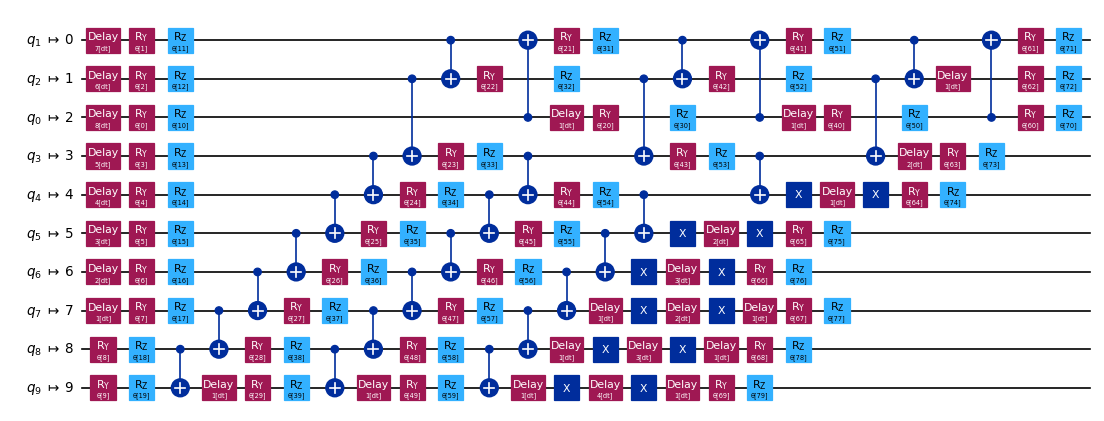

In [5]:
target = backend.target
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
pm.scheduling = PassManager(
    [
        ALAPScheduleAnalysis(durations=target.durations()),
        PadDynamicalDecoupling(
            durations=target.durations(),
            dd_sequence=[XGate(), XGate()],
            pulse_alignment=target.pulse_alignment,
        ),
    ]
)
ansatz_ibm = pm.run(ansatz)
observable_ibm = hamiltonian.apply_layout(ansatz_ibm.layout)
ansatz_ibm.draw("mpl", scale=0.6, style="iqp", fold=-1, idle_wires=False)

## Step 3: Execute

Iters. done: 101 [Current cost: -5.696214881088376]]

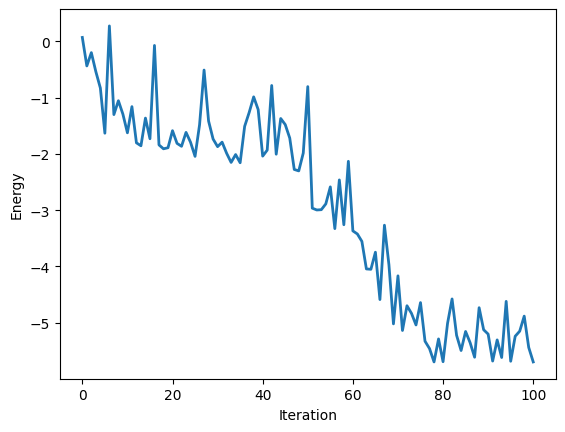

In [6]:
# SciPy minimizer routine
def cost_func(
    params: Sequence,
    ansatz: QuantumCircuit,
    hamiltonian: SparsePauliOp,
    estimator: Estimator,
) -> float:
    """Ground state energy evaluation."""
    return (
        estimator.run([(ansatz, hamiltonian, [params])])
        .result()[0]
        .data.evs[0]
    )
 
 
num_params = ansatz_ibm.num_parameters
params = 2 * np.pi * np.random.random(num_params)
 
callback_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
 
# Evaluate the problem on a QPU by using Qiskit IBM Runtime
with Session(backend=backend) as session:
    estimator = Estimator(backend=backend)
    callback = build_callback(
        ansatz_ibm, observable_ibm, estimator, callback_dict
    )
    res = minimize(
        cost_func,
        x0=params,
        args=(ansatz_ibm, observable_ibm, estimator),
        callback=callback,
        method="cobyla",
        options={"maxiter": 100},
    )
 
visualize_results(callback_dict)

## Step 4: Post-process and return result in desired classical format

In [7]:
print(f'Estimated ground state energy: {res["fun"]}')

Estimated ground state energy: -5.696214881088376
